<a href="https://colab.research.google.com/github/Apichaya-bu/229352-stat-learning-for-data2/blob/main/%E0%B8%AA%E0%B8%B3%E0%B9%80%E0%B8%99%E0%B8%B2%E0%B8%82%E0%B8%AD%E0%B8%87_Lab09_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #9

[Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/)

In [1]:
%%capture
!git clone https://github.com/donlapark/ds352-labs.git

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

## Training a neural network in PyTorch

### Chihuahua or Muffin?

<center><img src="https://donlapark.pages.dev/229352/lab09-preview.jpg" width="500"/></center>

### 1. Data preparation

#### Load images, resize them to 128x128, and normalize the pixels to be in 0 - 1 range

In [3]:
transform = transforms.Compose([transforms.Resize((128, 128)),
                                transforms.ToTensor()])  # transform pixels to be in 0 - 1 range

dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/train",
                                         transform=transform)

#### Split the dataset into training (80%), validation (20%)

In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#### Load the datasets into DataLoader

In [5]:
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=10,
                          shuffle=True)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=len(val_dataset),
                        shuffle=False)

#### Do the same for the test images

In [6]:
test_dataset = datasets.ImageFolder(root="ds352-labs/lab09-data/test",
                                    transform=transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=len(test_dataset),
                         shuffle=False)

#### Looking at the first minibatch

In [7]:
train_batches = iter(train_loader)
X, y = next(train_batches)

print(X.shape)  # (batch_size, channel, height, weight)
print(y.shape)

torch.Size([10, 3, 128, 128])
torch.Size([10])


#### Visualize the first four images in the batch

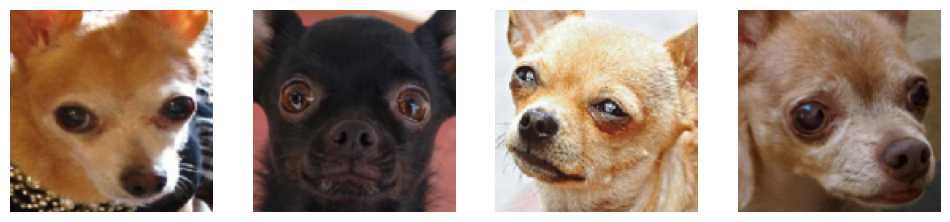

tensor([0, 0, 0, 0])


In [8]:
X = X[:4]  # Select the first 4 images
X = X.numpy().transpose(0, 2, 3, 1)  # Convert from (B, C, H, W) to (B, H, W, C)

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    axes[i].imshow(X[i])
    axes[i].axis('off')
plt.show()

print(y[:4])

### 2. Build a simple logistic regression

<center><img src="https://donlapark.pages.dev/229352/logistic.png" width="300"/></center>

The most important component of the model class is the `__init__` method and the `forward` method.  

[Linear layer in Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)

[Activation functions in PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity). The most important ones are [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), [Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html), [Softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html), [Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html).

In [10]:
class SimpleLogisticRegression(nn.Module):
    def __init__(self):
        super(SimpleLogisticRegression, self).__init__()
        # Input images are 128x128 with 3 channels, so 128*128*3 features
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(128 * 128 * 3, 1)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        # For binary classification, typically a sigmoid is applied here
        # but CrossEntropyLoss expects raw scores (logits) if using it directly for binary
        # or BCELossWithLogits for better numerical stability. Given CrossEntropyLoss
        # is used later, it usually expects 2 output classes or logits for binary.
        # The problem description image shows a single output for logistic regression.
        # Let's keep it as a single output logit for now.
        return x

### 3. Initialize training components

#### Initialize the model and loss function

[Loss functions in PyTorch](https://pytorch.org/docs/stable/nn.html#loss-functions). Most important ones are [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [Binary cross, entropy](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html), [Categorical cross entropy](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

In [11]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()

#### Manually setting initial weights to zero for demonstration

In [12]:
with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

#### Create two lists to collect training and validation losses

In [13]:
# List to store the loss values for plotting
train_losses = []
val_losses = []

#### Specify the learning rate

In [14]:
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

### 4. Training the model with gradient descent

#### Convert the dataloader into minibatches

In [38]:
for X, y in train_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]

    y = y.to(torch.float32)

    loss = criterion(y_hat, y)

    loss.backward()

    optimizer.step()

    model.zero_grad()

#### Make a prediction on the minibatch (Forward pass)

In [18]:

#y_hat = y_hat[:, 0]
y = y.to(torch.float32)

#### Calculate the loss function

Recall that `criterion()` is our binary cross-entropy loss (`BCELoss`).

In [28]:
# Compute the loss
loss = criterion(y_hat, y)

#### Calculate the gradient (Backward pass)

In [39]:
# Backward pass: compute the gradient of the loss w.r.t. model parameters
loss.backward()


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

#### Perform a gradient descent step

Careful! We must not include this step in the gradient calculation, hence the use of `with torch.no_grad()`.

In [40]:
optimizer.step()

model.zero_grad()

#### Do the same for the validation set

Careful! Anything in the validation step must not be included in the gradient calculation, hence the use of `with torch.no_grad()`.

In [24]:
with torch.no_grad():
  for X, y in val_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)
    print(y_hat, y)
    val_loss = criterion(y_hat, y)
    val_losses.append(val_loss.item())

tensor([-2.4153e+00, -9.5560e-01,  1.2002e+00, -7.9276e+00, -6.3648e+00,
        -4.5260e+00, -3.3947e+00, -5.7781e-01, -8.4728e+00, -4.6817e+00,
        -9.5895e-01, -4.0721e+00, -4.1184e-03, -2.7025e+00, -4.3011e+00,
        -1.8810e+00,  2.4014e+00, -5.4613e+00, -5.6205e+00, -4.7655e+00,
        -2.8584e+00, -4.0797e+00, -3.9381e+00,  1.2690e+00]) tensor([1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0.,
        0., 0., 1., 1., 0., 1.])


In [25]:
print(train_losses)
print(val_losses)

[9.832923889160156]
[51.4047966003418]


#### Combine everything together.

Repeat the previous steps for 20 **epochs** and plot the training and validation losses.

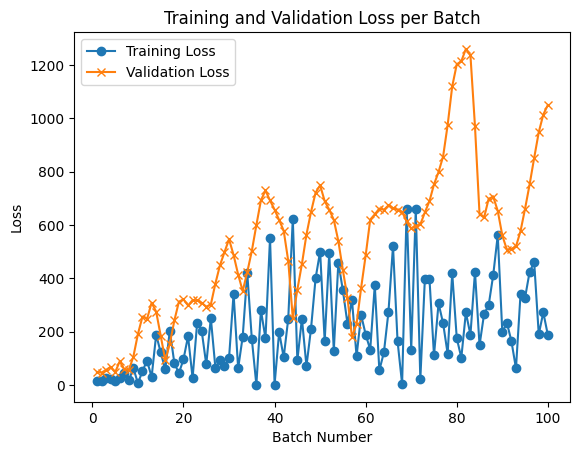

In [26]:
model = SimpleLogisticRegression()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

with torch.no_grad():
  for layer in model.modules():
      if isinstance(layer, nn.Linear):
          layer.weight.zero_()
          layer.bias.zero_()

train_losses = []
val_losses = []

learning_rate = 1e-4

for epoch in range(10):
  for X, y in train_loader:
    y_hat = model(X)
    y_hat = y_hat[:, 0]
    y = y.to(torch.float32)

    loss = criterion(y_hat, y)
    train_losses.append(loss.item())

    loss.backward()
    optimizer.step()

    model.zero_grad()

    with torch.no_grad():
      for X, y in val_loader:
        y_hat = model(X)
        y_hat = y_hat[:, 0]
        y = y.to(torch.float32)
        val_loss = criterion(y_hat, y)
        val_losses.append(val_loss)

# Plot the training and validation loss
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='x', label='Validation Loss')
plt.title('Training and Validation Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Exercise

In this exercise, we will add more layers to our classification model.

<img src="https://donlapark.pages.dev/229352/lab09-architecture.png" width="450"/>

1. Create a neural network with 3 hidden layers as shown in the picture.

2. Train the model with learning rate = 1e-2, 1e-3, 1e-4, 1e-5, and answer the following questions.
    2.1 What value of learning rate do you **think** is the best? Please explain your reason.
    2.2 What happens to the training losses if your learning rate is too large?
    2.3 What happens to the training losses if your learning rate is too small?

3. After finish training your model. Make the predictions on the test set and compute the accuracy. You may use the provided code below.

4. Use `plt.imshow()` to display at least four images that are incorrectly classified by this model.

In [32]:
# Use this code to calculate test accuracy
with torch.no_grad():
  test_batches = iter(test_loader)
  X, y = next(test_batches)
  y_hat = model(X)
  y_hat = y_hat[:, 0]
  y_hat = (y_hat > 0.5).float()  # the predictions
  ##TODO: compute accuracy


In [34]:
#1
import torch.nn as nn
import torch.nn.functional as F

class ThreeLayerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * 128 * 128, 128) # Layer 1
        self.fc2 = nn.Linear(128, 64)            # Layer 2
        self.fc3 = nn.Linear(64, 32)             # Layer 3
        self.fc4 = nn.Linear(32, 2)              # Output Layer (2 classes)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x)) # ใช้ ReLU เป็น activation function
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        logits = self.fc4(x)
        return logits

model = ThreeLayerNet()
print(model)


ThreeLayerNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=49152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)


Training with Learning Rate: 0.01
  Epoch 1, Loss: 9.1127
  Epoch 2, Loss: 2.0716
  Epoch 3, Loss: 0.6985
  Epoch 4, Loss: 0.7001
  Epoch 5, Loss: 0.3951
------------------------------
Training with Learning Rate: 0.001
  Epoch 1, Loss: 0.8010
  Epoch 2, Loss: 0.6421
  Epoch 3, Loss: 0.4014
  Epoch 4, Loss: 0.4555
  Epoch 5, Loss: 0.3643
------------------------------
Training with Learning Rate: 0.0001
  Epoch 1, Loss: 0.7271
  Epoch 2, Loss: 0.6805
  Epoch 3, Loss: 0.6619
  Epoch 4, Loss: 0.6258
  Epoch 5, Loss: 0.5847
------------------------------
Training with Learning Rate: 1e-05
  Epoch 1, Loss: 0.6950
  Epoch 2, Loss: 0.6833
  Epoch 3, Loss: 0.6772
  Epoch 4, Loss: 0.6646
  Epoch 5, Loss: 0.6503
------------------------------


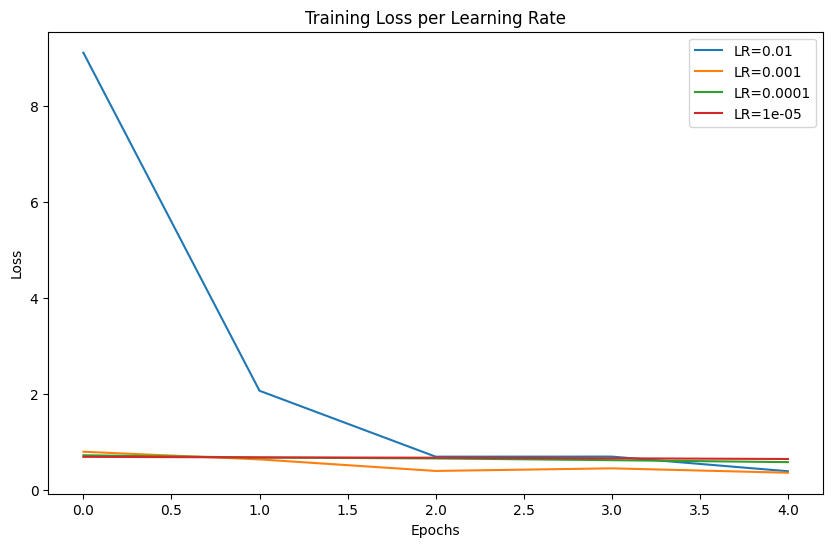

In [35]:
#2
import torch.optim as optim
import matplotlib.pyplot as plt

learning_rates = [1e-2, 1e-3, 1e-4, 1e-5]
results = {}

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    print(f"Training with Learning Rate: {lr}")

    model = ThreeLayerNet()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    # เทรน 5 Epochs
    for epoch in range(5):
        running_loss = 0.0
        for i, (X, y) in enumerate(train_loader):
            # 1. Forward pass
            y_hat = model(X)
            loss = criterion(y_hat, y)

            # 2. Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"  Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    results[lr] = losses
    print("-" * 30)

#กราฟเปรียบเทียบ
plt.figure(figsize=(10, 6))
for lr, loss_vals in results.items():
    plt.plot(loss_vals, label=f'LR={lr}')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss per Learning Rate')
plt.show()


2.1 What value of learning rate do you think is the best?
ตอบ: โดยทั่วไปสำหรับ Adam optimizer ค่า 1e-3 (0.001) มักจะเป็นค่าที่ดีที่สุด กราฟ Loss จะลดลงอย่างต่อเนื่องและรวดเร็วพอสมควร (ไม่แกว่งเกินไปและไม่ช้าเกินไป)

 2.2 What happens if your learning rate is too large? (เช่น 1e-2)
ตอบ: ค่า Loss จะ แกว่ง (Oscillate) หรืออาจจะไม่ลดลงเลย (Diverge) กราฟจะกระโดดไปมา หรือค่า Loss อาจพุ่งสูงขึ้นเรื่อยๆ เพราะการปรับ Weight ก้าวกระโดดข้ามจุดต่ำสุดไป

2.3 What happens if your learning rate is too small? (เช่น 1e-5)
ตอบ: ค่า Loss จะลดลง ช้ามากๆ (Slow convergence) ต้องใช้เวลาเทรน (Epochs) จำนวนมากเพื่อให้โมเดลฉลาดขึ้น หรืออาจจะไปติดอยู่ใน Local Minima ได้ง่าย

In [36]:
#3

correct = 0
total = 0

model.eval()

with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)

        _, predicted = torch.max(outputs.data, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')


Test Accuracy: 70.00%


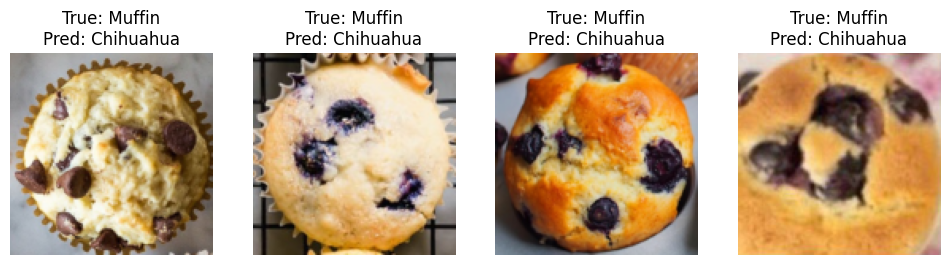

In [37]:
#4
import numpy as np

incorrect_images = []
incorrect_labels = []
predicted_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        idxs = (predicted != y).nonzero()

        for idx in idxs:
            if len(incorrect_images) < 4: # เอาแค่ 4 รูป
                idx = idx.item()
                img = X[idx].cpu()
                incorrect_images.append(img)
                incorrect_labels.append(y[idx].item())
                predicted_labels.append(predicted[idx].item())
            else:
                break
        if len(incorrect_images) >= 4:
            break

# แสดงรูปภาพ
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
classes = ['Chihuahua', 'Muffin']

for i in range(4):
    if i < len(incorrect_images):
        img = incorrect_images[i].permute(1, 2, 0).numpy()

        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[incorrect_labels[i]]}\nPred: {classes[predicted_labels[i]]}")
        axes[i].axis('off')

plt.show()
